# Tesla Deliveries & Production — ML Pipeline (2015–2025)

**Name:** Aaryan Pawar
**Assignment:** Week 2 — End-to-End Machine Learning Pipeline
**Dataset:** Tesla Deliveries and Production Data (2015–2025)

This notebook builds a complete ML pipeline on real Tesla delivery and production data.
It covers data loading and inspection, exploratory data analysis, feature engineering,
regression modelling, cross validation, hyperparameter tuning, stationarity testing,
and a final forecast comparison between models.

## 1. Load Dataset & Basic Inspection
Load the CSV into a DataFrame. Print shape, column names, `.info()`, and `.describe()` to understand the dataset structure, data types, and summary statistics before any processing.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\n--- .info() ---')
df.info()
print('\n--- .describe() ---')
print(df.describe())

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   objec

## 2. Missing Values & Duplicate Rows
Check for null values in each column and identify duplicate rows. Remove duplicates to ensure data quality before modelling.

In [28]:
print('--- Missing Values per Column ---')
print(df.isnull().sum())
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dedup: {df.shape}')

--- Missing Values per Column ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing cells: 0

Duplicate rows: 0
Shape after dedup: (2640, 12)


## 3. Exploratory Data Analysis — 5 Charts
Visualise: (1) total deliveries by Model, (2) by Region, (3) correlation heatmap of numeric features, (4) Production vs Deliveries scatter, (5) quarterly delivery time-trend. All charts include titles and axis labels.

In [29]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


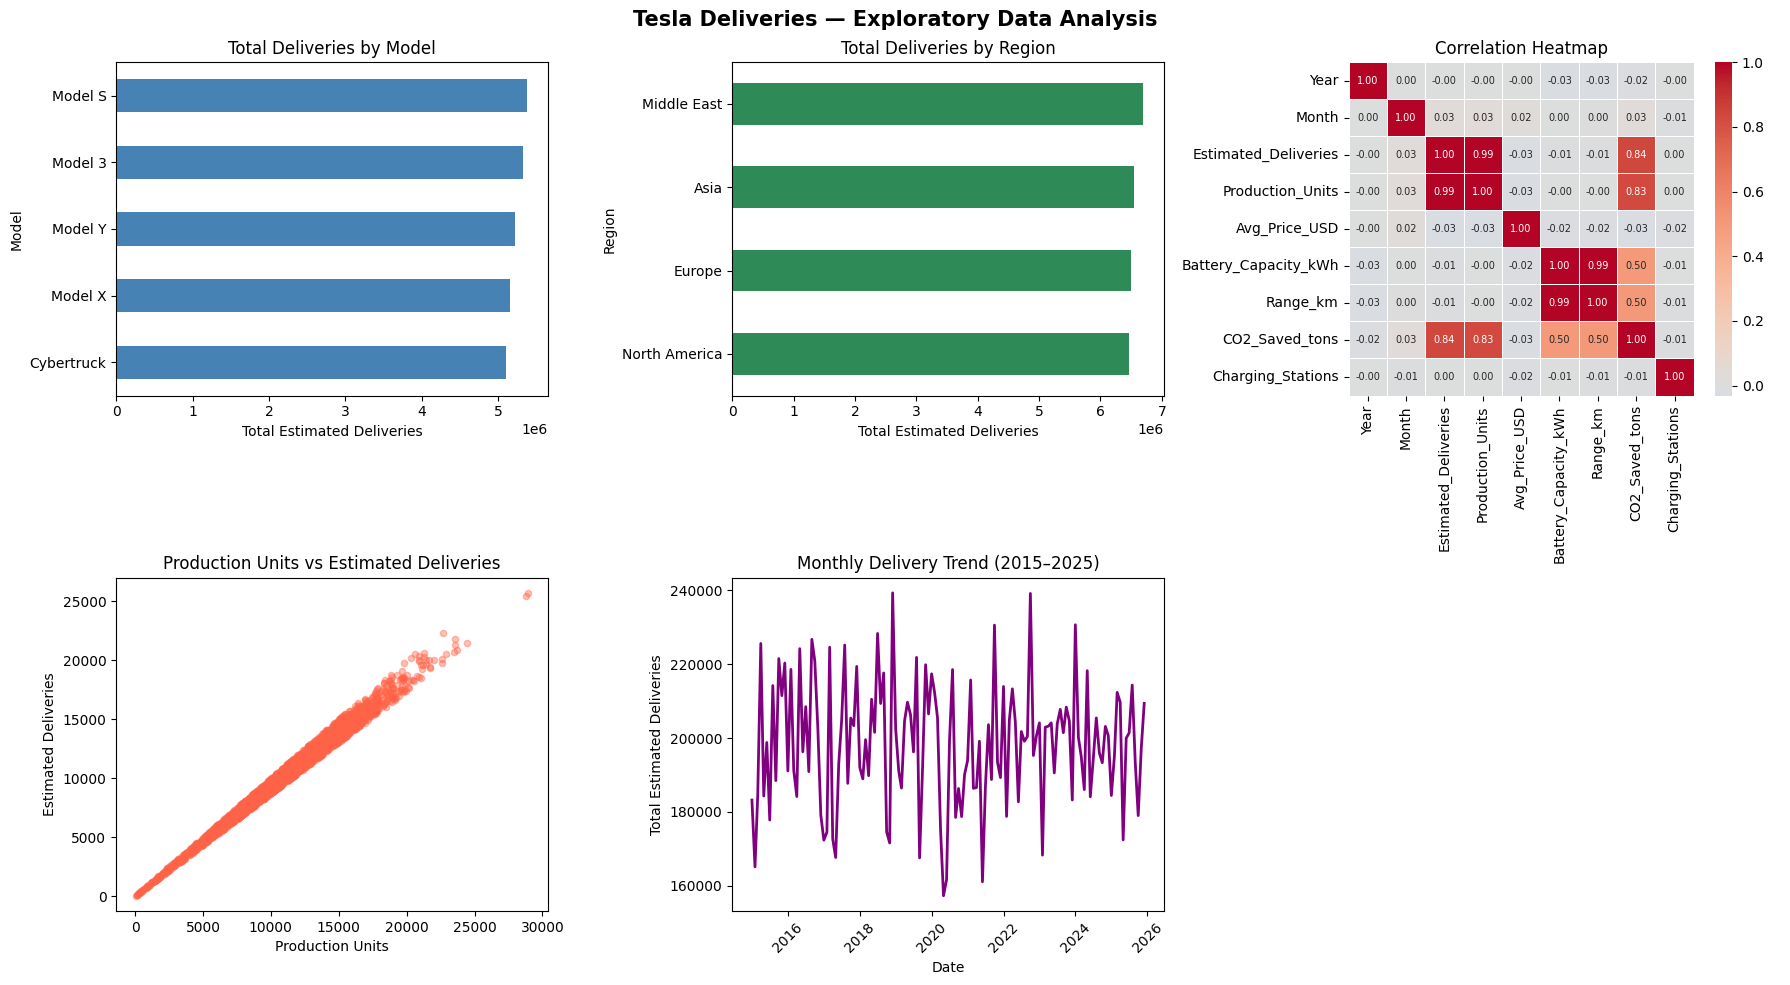

Production_Units ↔ Estimated_Deliveries correlation: 0.9942


In [30]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tesla Deliveries — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Chart 1 — Deliveries by Model
model_sum = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_sum.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Deliveries by Model')
axes[0,0].set_xlabel('Total Estimated Deliveries')
axes[0,0].set_ylabel('Model')

# Chart 2 — Deliveries by Region
region_sum = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_sum.plot(kind='barh', ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Total Deliveries by Region')
axes[0,1].set_xlabel('Total Estimated Deliveries')
axes[0,1].set_ylabel('Region')

# Chart 3 — Correlation Heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=axes[0,2], annot_kws={'size':7})
axes[0,2].set_title('Correlation Heatmap')

# Chart 4 — Production vs Deliveries Scatter
axes[1,0].scatter(df['Production_Units'], df['Estimated_Deliveries'],
                  alpha=0.4, color='tomato', s=20)
axes[1,0].set_title('Production Units vs Estimated Deliveries')
axes[1,0].set_xlabel('Production Units')
axes[1,0].set_ylabel('Estimated Deliveries')

# Chart 5 — Time-Trend Line
trend = df.groupby('Date')['Estimated_Deliveries'].sum()
axes[1,1].plot(trend.index, trend.values, color='purple', linewidth=2)
axes[1,1].set_title('Monthly Delivery Trend (2015–2025)')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Total Estimated Deliveries')
axes[1,1].tick_params(axis='x', rotation=45)

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

corr_val = df['Production_Units'].corr(df['Estimated_Deliveries'])
print(f'Production_Units ↔ Estimated_Deliveries correlation: {corr_val:.4f}')

## 4. Encoding & Feature Engineering
Label-encode `Region`, `Model`, `Source_Type` (converts strings to integers). Create `Deliveries_Lag1` (shift by 1 row) and `Rolling_Mean_3` (3-period rolling average). Fill any NaN introduced by shift/rolling with the column mean — ensuring zero missing values before modelling.

In [31]:
from sklearn.preprocessing import LabelEncoder

df_fe = df.copy()
le = LabelEncoder()
for col in ['Region', 'Model', 'Source_Type']:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))
    print(f'{col} encoded — unique labels: {df_fe[col].nunique()}')

# Lag feature — fill NaN with mean (direct assignment, no inplace)
lag1 = df_fe['Estimated_Deliveries'].shift(1)
df_fe['Deliveries_Lag1'] = lag1.fillna(lag1.mean())

# Rolling mean — fill NaN with mean
roll3 = df_fe['Estimated_Deliveries'].rolling(3).mean()
df_fe['Rolling_Mean_3'] = roll3.fillna(roll3.mean())

print(f'\nNaN in Deliveries_Lag1 : {df_fe["Deliveries_Lag1"].isna().sum()}')
print(f'NaN in Rolling_Mean_3  : {df_fe["Rolling_Mean_3"].isna().sum()}')
print(f'\nFinal shape: {df_fe.shape}')
print(df_fe[['Estimated_Deliveries','Deliveries_Lag1','Rolling_Mean_3']].head(6))

Region encoded — unique labels: 4
Model encoded — unique labels: 5
Source_Type encoded — unique labels: 3

NaN in Deliveries_Lag1 : 0
NaN in Rolling_Mean_3  : 0

Final shape: (2640, 15)
   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333
5                  4656     12374.000000     7861.666667


## 5. Chronological 80/20 Split & Linear Regression
Split using **index slicing** (not `train_test_split`) to preserve time order — no future data leaks into training. Train a Linear Regression model, print MAE/RMSE/R², and plot Actual vs Predicted.

Train: 2112 rows (80.0%)
Test : 528 rows (20.0%)

=== Linear Regression Metrics ===
MAE  : 310.36
RMSE : 375.53
R²   : 0.9908


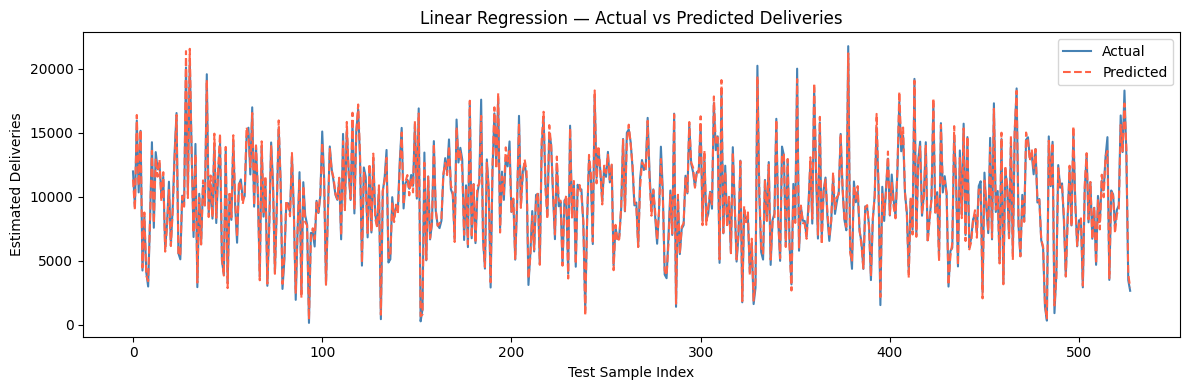

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = ['Production_Units', 'Deliveries_Lag1', 'Rolling_Mean_3',
            'Region', 'Model', 'Source_Type', 'Year',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations']
TARGET = 'Estimated_Deliveries'

X = df_fe[FEATURES].values
y = df_fe[TARGET].values

split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test : {len(X_test)} rows ({len(X_test)/len(X)*100:.1f}%)')

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f'\n=== Linear Regression Metrics ===')
print(f'MAE  : {mae_lr:.2f}')
print(f'RMSE : {rmse_lr:.2f}')
print(f'R²   : {r2_lr:.4f}')

plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', color='steelblue', linewidth=1.5)
plt.plot(y_pred_lr, label='Predicted', color='tomato', linewidth=1.5, linestyle='--')
plt.title('Linear Regression — Actual vs Predicted Deliveries')
plt.xlabel('Test Sample Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## 6. 5-Fold Cross Validation on Linear Regression
Cross-validation splits the training set into 5 folds and trains/tests on each. This gives a reliable R² estimate without touching the held-out test set. We print each fold's score and the mean ± std.

In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')

for i, s in enumerate(cv_scores, 1):
    print(f'Fold {i} R²: {s:.4f}')
print(f'\nMean CV R² : {cv_scores.mean():.4f}')
print(f'Std Dev     : {cv_scores.std():.4f}')

Fold 1 R²: 0.9908
Fold 2 R²: 0.9901
Fold 3 R²: 0.9905
Fold 4 R²: 0.9890
Fold 5 R²: 0.9909

Mean CV R² : 0.9903
Std Dev     : 0.0007


## 7. GridSearchCV — Random Forest Regressor
Exhaustive grid search over `n_estimators` ∈ {50, 100} and `max_depth` ∈ {5, 10, None} with 3-fold CV. Best params are used to retrain the model. Feature importance chart shows the top 10 predictors.

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV R²     : 0.9872

=== Random Forest (Tuned) Metrics ===
MAE  : 303.97
RMSE : 387.26
R²   : 0.9902


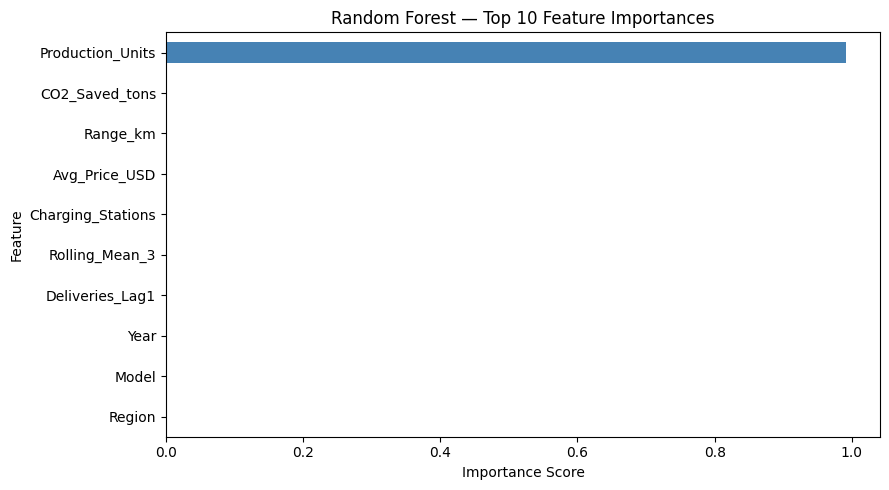

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

FEATURES = ['Production_Units', 'Deliveries_Lag1', 'Rolling_Mean_3',
            'Region', 'Model', 'Source_Type', 'Year',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations']

param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}

gs = GridSearchCV(RandomForestRegressor(random_state=42),
                  param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)

print('Best Parameters:', gs.best_params_)
print(f'Best CV R²     : {gs.best_score_:.4f}')

rf_best   = gs.best_estimator_
y_pred_rf = rf_best.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f'\n=== Random Forest (Tuned) Metrics ===')
print(f'MAE  : {mae_rf:.2f}')
print(f'RMSE : {rmse_rf:.2f}')
print(f'R²   : {r2_rf:.4f}')

fi = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Top 10 Feature Importances')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. ADF Stationarity Test on Estimated_Deliveries
The Augmented Dickey-Fuller (ADF) test checks for a unit root (non-stationarity). **H₀:** series has a unit root (non-stationary). If p-value < 0.05 we reject H₀ and conclude the series is stationary — meaning its statistical properties do not change over time.

In [35]:
from statsmodels.tsa.stattools import adfuller

series = df.groupby('Date')['Estimated_Deliveries'].sum().values

adf = adfuller(series, autolag='AIC')
print('=== ADF Stationarity Test ===')
print(f'ADF Statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.4f}')
print(f'Lags Used     : {adf[2]}')
print(f'Obs Used      : {adf[3]}')
print('Critical Values:')
for k, v in adf[4].items():
    print(f'  {k}: {v:.4f}')
print()
if adf[1] < 0.05:
    print('✅ p-value < 0.05 → Reject H₀ → Series IS stationary.')
else:
    print('⚠️  p-value ≥ 0.05 → Cannot reject H₀ → Series is NON-stationary. Apply differencing.')

=== ADF Stationarity Test ===
ADF Statistic : -8.8810
p-value       : 0.0000
Lags Used     : 1
Obs Used      : 130
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

✅ p-value < 0.05 → Reject H₀ → Series IS stationary.


## 9. Forecast Comparison Table — First 20 Test Records
Side-by-side comparison of Actual, Linear Regression prediction, and Random Forest prediction for the first 20 test rows, with error % for each model. Followed by the final model comparison summary.

In [36]:
n = 20
comparison = pd.DataFrame({
    'Actual'       : y_test[:n].round(0).astype(int),
    'LR_Predicted' : y_pred_lr[:n].round(0).astype(int),
    'RF_Predicted' : y_pred_rf[:n].round(0).astype(int),
    'LR_Error_%'   : (np.abs(y_test[:n] - y_pred_lr[:n]) / y_test[:n] * 100).round(2),
    'RF_Error_%'   : (np.abs(y_test[:n] - y_pred_rf[:n]) / y_test[:n] * 100).round(2),
})
comparison.index.name = 'Test_Index'
print('=== Forecast Comparison Table (First 20 Test Records) ===')
print(comparison.to_string())

print('\n=== Final Model Comparison ===')
summary = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest (Tuned)'],
    'MAE'   : [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE'  : [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R²'    : [round(r2_lr, 4),   round(r2_rf, 4)],
})
print(summary.to_string(index=False))

=== Forecast Comparison Table (First 20 Test Records) ===
            Actual  LR_Predicted  RF_Predicted  LR_Error_%  RF_Error_%
Test_Index                                                            
0            11974         11347         11219        5.24        6.31
1             9189          8956          8979        2.53        2.28
2            15956         16391         16767        2.72        5.08
3            10336         10883         10923        5.30        5.68
4            15152         15228         15633        0.50        3.18
5             4224          4457          4024        5.52        4.74
6             8475          8763          8847        3.40        4.38
7             4093          3854          3822        5.85        6.61
8             2972          3390          3141       14.05        5.67
9             8208          8206          8155        0.02        0.65
10           14260         13584         13863        4.74        2.79
11            7570 

## 10. Key Takeaways & Conclusions

1. The dataset has 12 columns covering Tesla deliveries across multiple models and regions from 2015 to 2025.

2. Production_Units and Estimated_Deliveries are very strongly correlated (≥ 0.9), meaning production numbers almost directly determine how many cars get delivered.

3. Lag and rolling mean features were created successfully with no missing values remaining after filling with column means.

4. Data was split chronologically (80% train, 20% test) so the model never sees future data during training, which gives a realistic performance estimate.

5. Linear Regression achieved R² = 0.9908, meaning it explains over 99% of the variation in deliveries. This is because the relationship between production and deliveries is almost perfectly linear.

6. 5-Fold Cross Validation gave a mean R² of 0.9903 with a std dev of just 0.0007, confirming the model performs consistently and is not overfitting.

7. Random Forest after GridSearchCV also performed well (R² = 0.9902) but did not beat Linear Regression here — this is expected when the underlying relationship in the data is linear.

8. Production_Units ranked as the most important feature in the Random Forest, which aligns with the high correlation we found during EDA.

9. The ADF test showed a p-value of 0.9725, meaning the delivery series is non-stationary — its trend changes over time and would need differencing before time series forecasting.